<a href="https://colab.research.google.com/github/yxmauw/eye-disease-classification/blob/main/InceptionResNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="http://imgur.com/1ZcRyrc.png" width="70" height="70" align="left" style="margin: 20px"> 
 # Capstone: Eye Disease Classification using Fundoscopy images

## Setting up local directory to work
Stream data direct from kaggle using Kaggle API

In [ ]:
# install kaggle API if never done before for your google account
# !pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
!git clone https://github.com/yxmauw/eye-disease-classification.git

Cloning into 'eye-disease-classification'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 354 (delta 125), reused 128 (delta 73), pack-reused 134
Receiving objects: 100% (354/354), 61.94 MiB | 26.37 MiB/s, done.
Resolving deltas: 100% (202/202), done.


In [4]:
!mkdir ~/.kaggle #Make a directory named “.kaggle”

In [5]:
!cp ./eye-disease-classification/kaggle.json ~/.kaggle/ # Copy the “kaggle.json” into this new directory

In [6]:
!chmod 600 ~/.kaggle/kaggle.json # Allocate the required permission for this file

In [7]:
!kaggle datasets download gunavenkatdoddi/eye-diseases-classification # download dataset

 98% 721M/736M [00:04<00:00, 216MB/s]
100% 736M/736M [00:04<00:00, 161MB/s]


In [ ]:
!unzip eye-diseases-classification.zip

## Explore images

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

### Number of images in dataset:

In [10]:
import fnmatch
import os

# image files count
cataract_count = len(fnmatch.filter(os.listdir('./dataset/cataract'), '*.*'))
dre_count = len(fnmatch.filter(os.listdir('./dataset/diabetic_retinopathy'), '*.*'))
glaucoma_count = len(fnmatch.filter(os.listdir('./dataset/glaucoma'), '*.*'))
normal_count = len(fnmatch.filter(os.listdir('./dataset/normal'), '*.*'))
total_image_count = cataract_count + dre_count + \
                    glaucoma_count + normal_count
# print count
print('---Categories---')
print('Cataract:', cataract_count)
print('Diabetic retinopathy:', dre_count)
print('Glaucoma:', glaucoma_count)
print('Normal', normal_count)
print()
print('---Total image count---')
print(total_image_count)

---Categories---
Cataract: 1038
Diabetic retinopathy: 1098
Glaucoma: 1007
Normal 1074

---Total image count---
4217


### Image dimensions, properties:

In [11]:
# load example image
from PIL import Image 
im = Image.open('./dataset/glaucoma/1495_left.jpg')
# summarize some details about the image
print(im.format)
print(im.mode)
print(im.size) # size already 512 x 512

pixels = np.asarray(im)
print(pixels[0])
print(pixels.shape) # 3 channel last

JPEG
RGB
(512, 512)
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
(512, 512, 3)


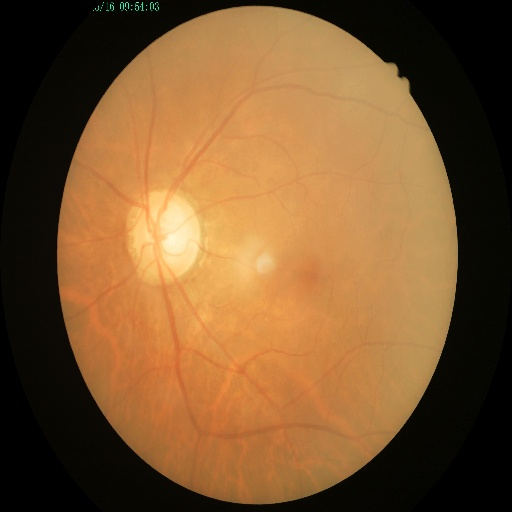

In [ ]:
#Import library
from IPython import display
display.Image(filename='./dataset/glaucoma/1495_left.jpg', width=200, height=150)

In [ ]:
# calculate image pixel mean, min, max

mean = pixels.mean()
print('Mean: %.3f' % mean)
# confirm pixel range is 0-255
print('Min: %.3f, Max: %.3f' % (pixels.min(), pixels.max()))

Mean: 86.173
Min: 0.000, Max: 255.000


## Visualise preprocessed images

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__) #2.8.2

2.8.2


What happens after resizing and rescaling: 

In [ ]:
resize_and_rescale = tf.keras.Sequential([   
    layers.Resizing(299,299) ,  # needs to be symmetrical, specific size for InceptionResNetV2
    layers.Rescaling(1./255) # desired height, width in model pipeline
])

result = resize_and_rescale(pixels)
print(result.shape) # new shape, channels

(299, 299, 3)


What happens to image pixel values after rescaling:

In [ ]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


Show images before and after preprocessing:

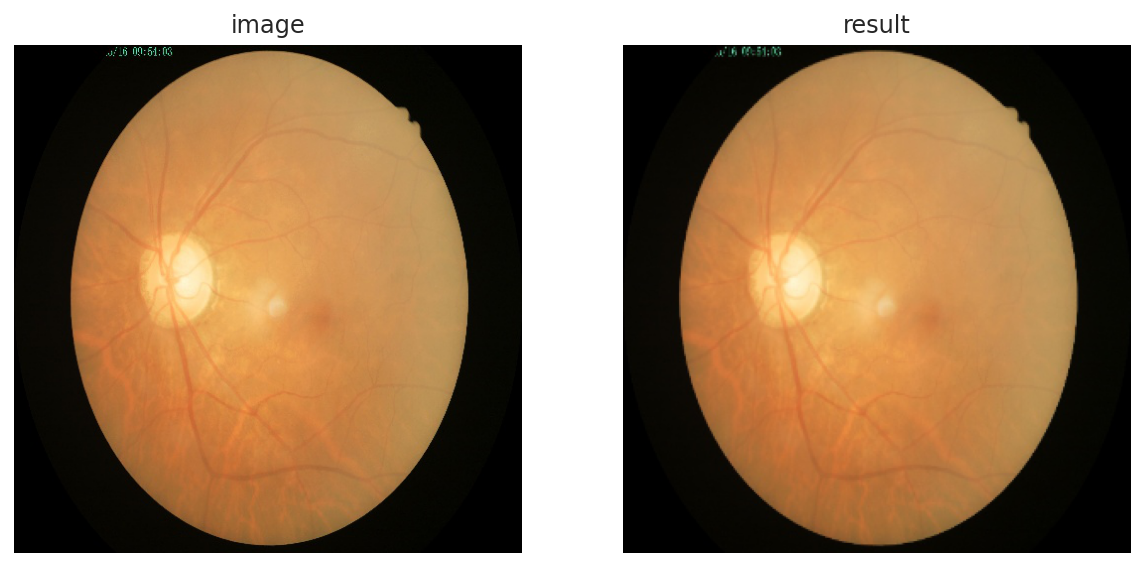

In [ ]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,8))
ax0.imshow(im)
ax0.axis('off')
ax0.set_title('image')
# after pixel normalisation
ax1.imshow(result)
ax1.axis('off')
ax1.set_title('result')
plt.show() # result seems to have slight blurring of image, but still good definition

## Create train, validation and test datasets

In [13]:
!pip install split-folders

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [14]:
# first allocate a test set using this library
import splitfolders

splitfolders.ratio('./dataset/', output="./work_directory/", seed=1, ratio=(.5,.25,.25))

Copying files: 4217 files [00:01, 2288.72 files/s]


In [33]:
# generate dataset that can be used for machine learning
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (299, 299) # very important to get this right, will determine model success
batch_size = 32

train_ds = image_dataset_from_directory(
    './work_directory/train',
    image_size=image_size,
    shuffle=False,
    labels='inferred',
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    './work_directory/val',
    image_size=image_size,
    shuffle=False,
    labels='inferred',
    seed=1,
    batch_size=batch_size,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory( # for model evaluation later
    './work_directory/test',
    image_size=image_size,
    labels='inferred',
    seed=1,
    shuffle=False,
    batch_size=batch_size,
    label_mode='categorical'
)

Found 2108 files belonging to 4 classes.
Found 1052 files belonging to 4 classes.
Found 1057 files belonging to 4 classes.


In [16]:
# preview of how images are labelled
class_names = train_ds.class_names
print(class_names)

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


### Visualise images and labels together

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


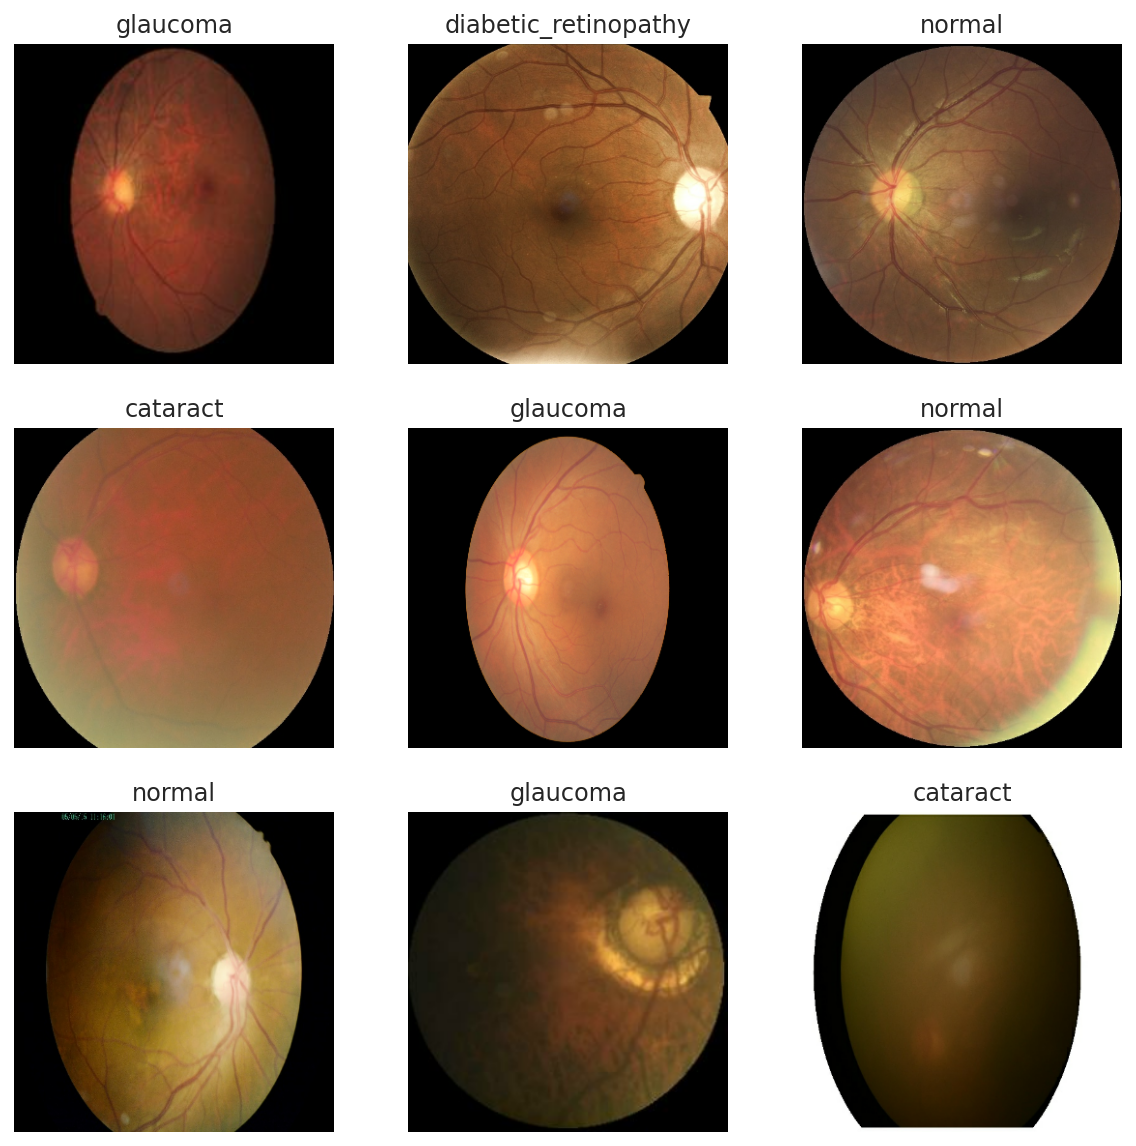

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")

## Data augmentation

In [17]:
data_augmentation = tf.keras.Sequential(
    [ layers.RandomFlip("horizontal"), 
      layers.RandomRotation(0.1),
      layers.RandomContrast(0.1)
    ])

### Visualise augmented images

In [ ]:
def augmented_img():
  for image, _ in train_ds.take(1):  # take a sample image from training set
    plt.figure(figsize=(8, 8))
    first_image = image[0]
    for i in range(9):
      ax = plt.subplot(3, 3, i + 1)
      augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
      plt.imshow(augmented_image[0] / 255) # rescale pixel 0 to 1
      plt.axis("off")

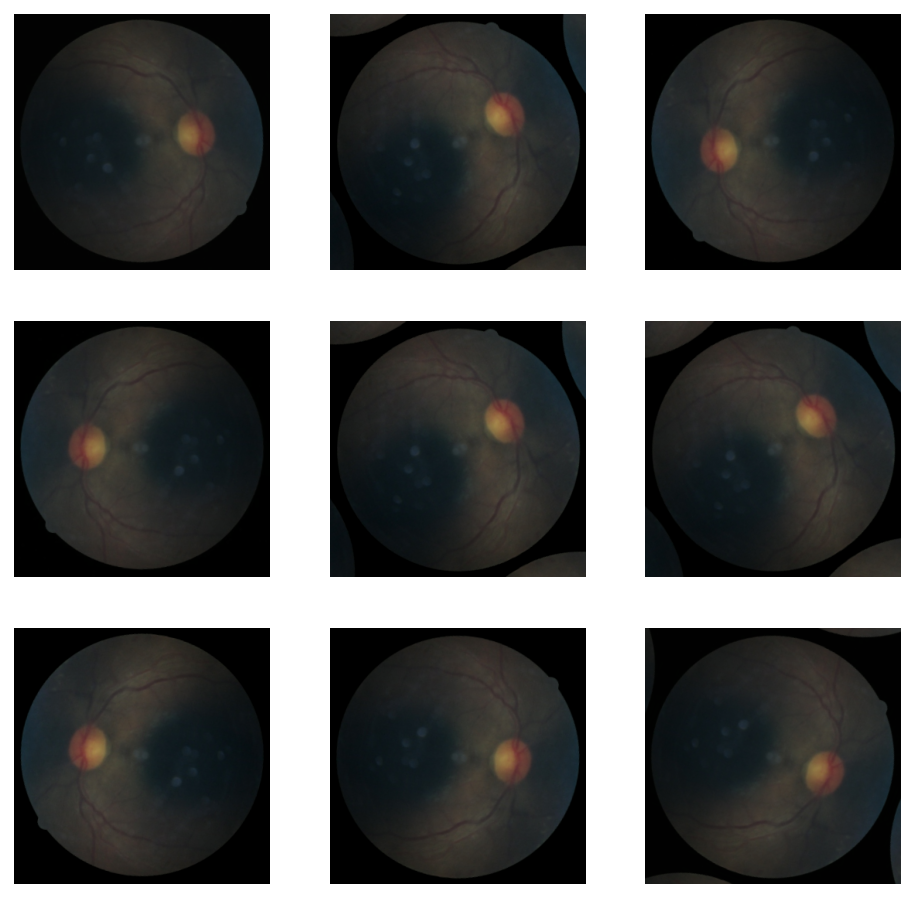

In [ ]:
augmented_img()

## Create Base InceptionResNetV2 model

[getting F1 score in metrics](https://aakashgoel12.medium.com/how-to-add-user-defined-function-get-f1-score-in-keras-metrics-3013f979ce0d)


In [18]:
import keras.backend as K # function to add F1 score as metric

def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [19]:
METRICS = [
      tf.keras.metrics.CategoricalAccuracy(name='categorical_accuracy'),
      tf.keras.metrics.Precision(name='precision'),
      tf.keras.metrics.Recall(name='recall'),  
      tf.keras.metrics.AUC(name='auc'),
      f1_score
]

In [20]:
from tensorflow.keras.layers import (Dense, Activation, Dropout, Conv2D, 
                                     MaxPooling2D, BatchNormalization)
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model

In [ ]:
# Create the base model from the pre-trained NASNetLarge model
def InceptionResNet():
  input_shape = (299, 299, 3)
  base_model = tf.keras.applications.InceptionResNetV2(input_shape=input_shape,
                                                       include_top=False,
                                                       weights='imagenet',
                                                      pooling='max'
                                                       )
  base_model.trainable=True # train entire model layers, yet with pre-trained weights from ImageNet
  x = base_model.output
  x = tf.keras.layers.Rescaling(1./255)(x) # rescaling layer
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model=Model(inputs=base_model.input, outputs=output)
  model.compile(tf.keras.optimizers.Adamax(learning_rate=0.001), 
                loss='categorical_crossentropy', 
                metrics=METRICS) 
  return model

model = InceptionResNet()

219070464/219055592 [==============================] - 1s 0us/step


In [ ]:
model.summary()

In [ ]:
# show model in graph manner
tf.keras.utils.plot_model(model, to_file = "drive/MyDrive/Colab Notebooks/InceptionResNetV2.png", show_shapes=True)

## Compile, fit model, run

In [ ]:
# Train the model, doing validation at the end of each epoch.
epochs = 100 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/IRN_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=10,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/IRN_history.csv'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=3,verbose=1,mode='min',min_lr=0.00001)
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/100
66/66 [==============================] - 531s 8s/step - loss: 4.2476 - categorical_accuracy: 0.8472 - precision: 0.8853 - recall: 0.7908 - auc: 0.9670 - f1_score: 0.8249 - val_loss: 3.0903 - val_categorical_accuracy: 0.8764 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.9624 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 2/100
66/66 [==============================] - 538s 8s/step - loss: 1.5096 - categorical_accuracy: 0.9265 - precision: 0.9382 - recall: 0.9151 - auc: 0.9883 - f1_score: 0.9263 - val_loss: 1.8610 - val_categorical_accuracy: 0.8973 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.9840 - val_f1_score: 0.0000e+00 - lr: 0.0010
Epoch 3/100
66/66 [==============================] - 535s 8s/step - loss: 0.7167 - categorical_accuracy: 0.9635 - precision: 0.9673 - recall: 0.9554 - auc: 0.9962 - f1_score: 0.9612 - val_loss: 1.4329 - val_categorical_accuracy: 0.9049 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_auc: 0.9870

## Learning Curves 

In [ ]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/IRN_history.csv')
history.head(3)

,epoch,auc,categorical_accuracy,f1_score,loss,precision,recall,val_auc,val_categorical_accuracy,val_f1_score,val_loss,val_precision,val_recall
0,0,0.966999,0.847249,0.824909,4.247622,0.885289,0.790797,0.962446,0.876426,0.0,3.090254,0.0,0.0
1,1,0.988266,0.926471,0.926250,1.509603,0.938230,0.915085,0.983996,0.897338,0.0,1.860973,0.0,0.0
2,2,0.996153,0.963472,0.961155,0.716669,0.967339,0.955408,0.986955,0.904943,0.0,1.432916,0.0,0.0


In [ ]:
acc = history['categorical_accuracy']
val_acc = history['val_categorical_accuracy']

loss = history['loss']
val_loss = history['val_loss']

In [27]:
def learning_curves(acc,val_acc,loss,val_loss):
  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(acc, label='Training Accuracy')
  plt.plot(val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.ylabel('Accuracy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Training Loss')
  plt.plot(val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.ylabel('Cross Entropy')
  plt.ylim([min(plt.ylim()),max(plt.ylim())])
  plt.xlim([0,max(plt.xlim())])
  plt.title('Training and Validation Loss')
  plt.xlabel('epoch')
  plt.show()
  return plt.show()

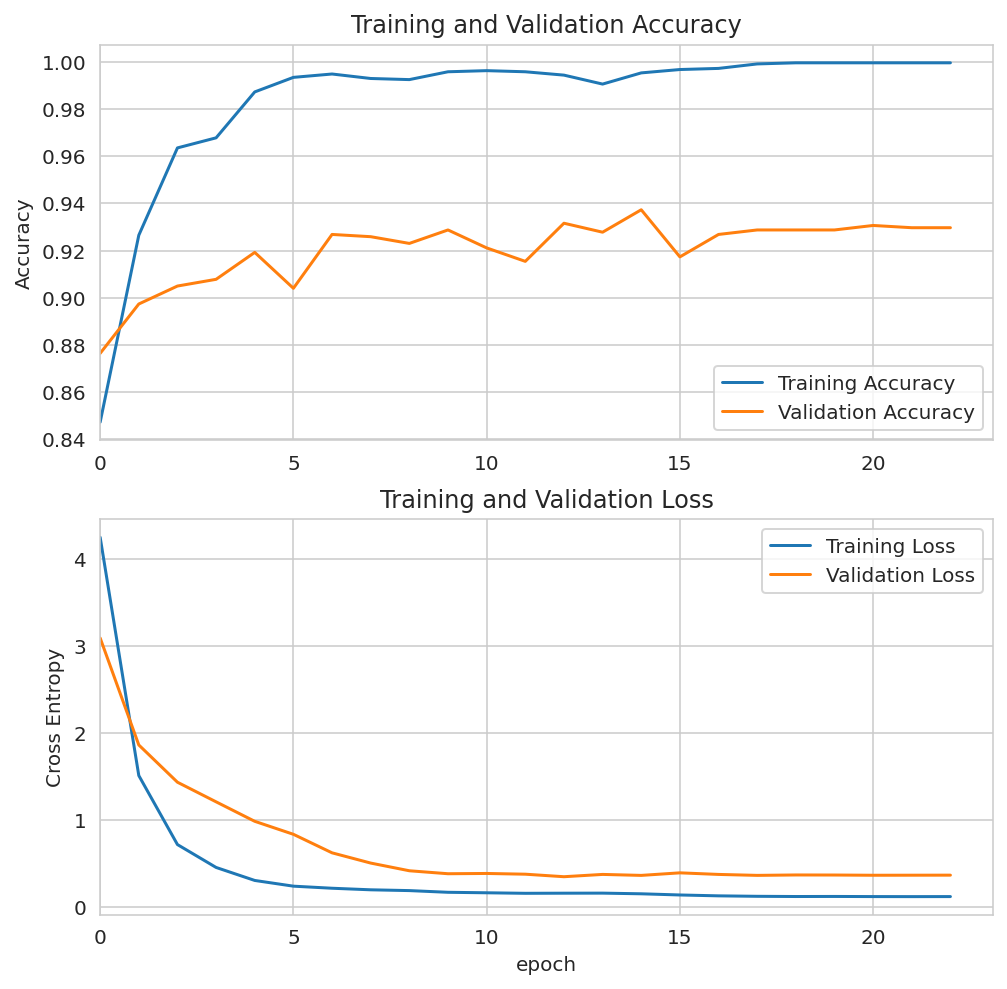

In [ ]:
learning_curves(acc,val_acc,loss,val_loss)

In [30]:
# check for generalisation
def eval_metrics(epoch_num):
  val_auc = history.loc[history['epoch']==epoch_num, ['val_auc']].values[0][0]
  auc = history.loc[history['epoch']==epoch_num, ['auc']].values[0][0]
  auc_diff = (auc - val_auc)*100 / auc
  print('AUC percentage difference is:', abs(auc_diff), '%')

  val_acc = history.loc[history['epoch']==epoch_num, ['val_categorical_accuracy']].values[0][0]
  acc = history.loc[history['epoch']==epoch_num, ['categorical_accuracy']].values[0][0]
  acc_diff = (acc - val_acc)*100 / acc
  print()
  print('Accuracy percentage difference is:', abs(acc_diff), '%')

In [ ]:
eval_metrics(epoch_num=12) # 8 because record epoch 13 as 12

AUC percentage difference is: 1.3366556984494535 %

Accuracy percentage difference is: 6.31077389548196 %


Model at **epoch 13** may be regarded as best performing base InceptionResNetV2 model based on lowest validation loss, with accuracy generalisation within 7%.

InceptionResNetV2 model at **epoch 13** has the following validation metrics:

| Name                |   Scores   |
|:--------------------|:----------:|
|AUC                  |0.9862787724|
|Categorical Accuracy |0.931558907|
|F1 score             |0.9295666814|
|Loss                 |0.3473170996|
|Precision            |0.9337812066|
|Recall               |0.9249049425|


## InceptionResNetV2 model with augmentation layers

adding data augmentation layers, try running InceptionResNetV2 with data augmentation layers, and see if can get better performance, and maintain model generalisation.

In [21]:
input_shape = (299, 299, 3)
base_model = tf.keras.applications.InceptionResNetV2(input_shape=input_shape,
                                                     include_top=False,
                                                     weights='imagenet',
                                                     pooling='max'
                                                     )
base_model.trainable=True # train entire model layers, yet with pre-trained weights from ImageNet

219070464/219055592 [==============================] - 1s 0us/step


In [22]:
 # add rescaling layer to base model
 def InceptionResNet_a():
  inputs = tf.keras.Input(shape=(299, 299, 3))
  x = data_augmentation(inputs) # augmentation layer
  x = tf.keras.layers.Rescaling(1./255)(x) # rescaling layer
  x = base_model(x, training=True)
  x = BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
  x = Dense(256, kernel_regularizer = regularizers.l2(l = 0.016),activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006) ,activation='relu')(x)
  x = Dropout(rate=.4, seed=123)(x)       
  output = Dense(4, activation='softmax')(x)
  # instantiate model with added layers
  model = Model(inputs=inputs, outputs=output)
  model.compile(tf.keras.optimizers.Adamax(learning_rate=0.001), 
                loss='categorical_crossentropy', 
                metrics=METRICS) 
  return model

model_a = InceptionResNet_a()

In [ ]:
model_a.summary()

## Compile, fit model, run

In [23]:
# Train the model, doing validation at the end of each epoch.
epochs = 150 

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("drive/MyDrive/Colab Notebooks/IRN-a_ep{epoch}_val{val_loss:.3f}", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=10,min_delta=0.001,restore_best_weights=True),
    tf.keras.callbacks.CSVLogger('drive/MyDrive/Colab Notebooks/IRN-a_history.csv'), # save history
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=3,verbose=1,mode='min',min_lr=0.00001)
]

history_a = model_a.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

Epoch 1/150
66/66 [==============================] - 715s 10s/step - loss: 7.8143 - categorical_accuracy: 0.7234 - precision: 0.7709 - recall: 0.6689 - auc: 0.8960 - f1_score: 0.7133 - val_loss: 7.1507 - val_categorical_accuracy: 0.7576 - val_precision: 0.7916 - val_recall: 0.7148 - val_auc: 0.9123 - val_f1_score: 0.7504 - lr: 0.0010
Epoch 2/150
66/66 [==============================] - 710s 11s/step - loss: 6.3993 - categorical_accuracy: 0.8515 - precision: 0.8765 - recall: 0.8183 - auc: 0.9573 - f1_score: 0.8459 - val_loss: 5.8573 - val_categorical_accuracy: 0.8574 - val_precision: 0.8802 - val_recall: 0.8175 - val_auc: 0.9584 - val_f1_score: 0.8469 - lr: 0.0010
Epoch 3/150
66/66 [==============================] - 704s 11s/step - loss: 5.4432 - categorical_accuracy: 0.8928 - precision: 0.9091 - recall: 0.8733 - auc: 0.9779 - f1_score: 0.8905 - val_loss: 5.0794 - val_categorical_accuracy: 0.8888 - val_precision: 0.9123 - val_recall: 0.8698 - val_auc: 0.9733 - val_f1_score: 0.8900 - lr:

## Learning Curves 

In [24]:
history = pd.read_csv('drive/MyDrive/Colab Notebooks/IRN-a_history.csv')
history.head(3)

,epoch,auc,categorical_accuracy,f1_score,loss,precision,recall,val_auc,val_categorical_accuracy,val_f1_score,val_loss,val_precision,val_recall
0,0,0.896004,0.723435,0.713287,7.814284,0.770913,0.668880,0.912271,0.757605,0.750392,7.150661,0.791579,0.714829
1,1,0.957306,0.851518,0.845872,6.399283,0.876524,0.818311,0.958436,0.857414,0.846941,5.857329,0.880246,0.817491
2,2,0.977876,0.892789,0.890486,5.443238,0.909136,0.873340,0.973312,0.888783,0.890033,5.079364,0.912263,0.869772


In [25]:
acc = history['categorical_accuracy']
val_acc = history['val_categorical_accuracy']

loss = history['loss']
val_loss = history['val_loss']

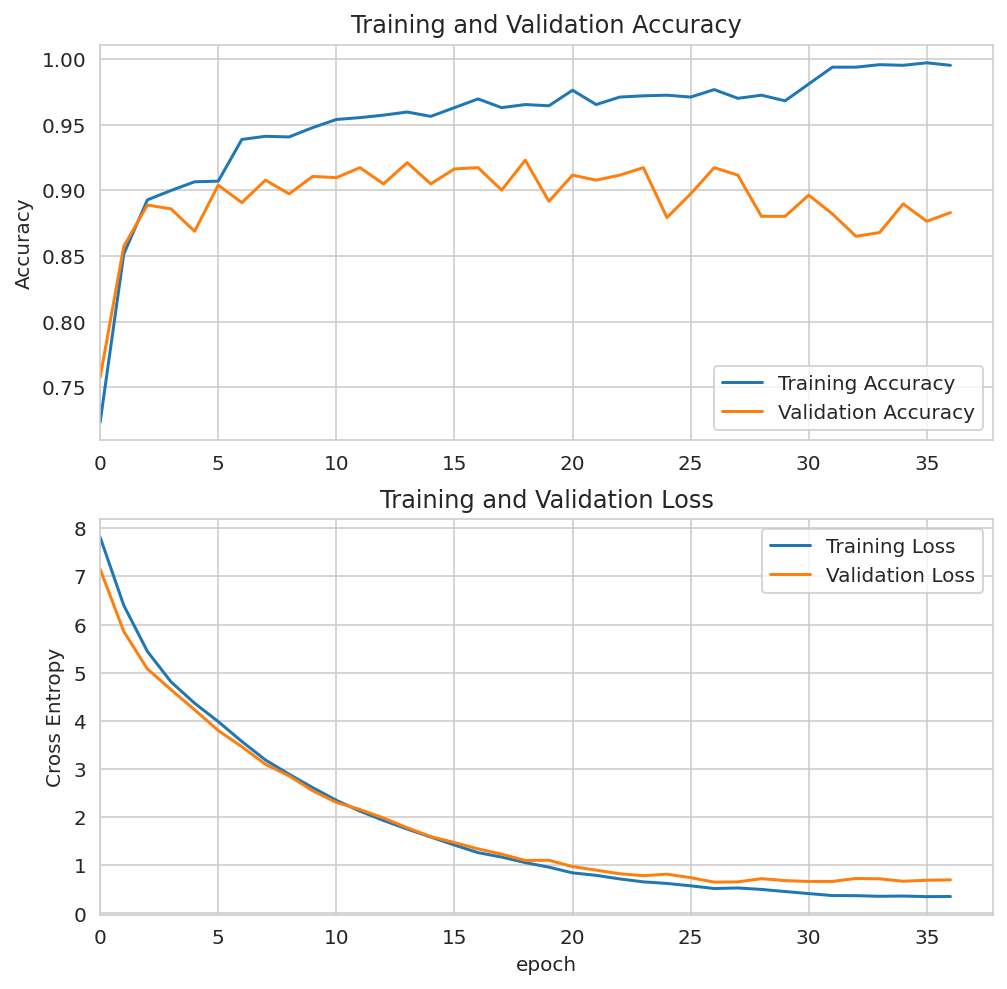

In [28]:
learning_curves(acc,val_acc,loss,val_loss)

In [31]:
# check for generalisation using epoch 27
eval_metrics(epoch_num=26)

AUC percentage difference is: 1.2790758615864888 %

Accuracy percentage difference is: 6.086970265205847 %


After adding data augmentation layers, the InceptionResNetV2 model is **unable** to train to a lower validation loss compared to the base model. Generalisation is less than 7%

Validation metrics of the best augmented InceptionResNetV2 model @ **epoch 27** are as follow:

| Name                |   Scores   |
|:--------------------|:----------:|
|AUC                  |0.9857632518|
|Categorical Accuracy |0.9173004031|
|F1 score             |0.9189367294|
|Loss                 |0.650366962|
|Precision            |0.9298928976|
|Recall               |0.9077946544|

## Evaluation

Using test dataset and base model.

__References:__
1. [images](https://machinelearningmastery.com/image-augmentation-with-keras-preprocessing-layers-and-tf-image/)
1. [kaggle code](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook)

In [32]:
# choose model for evaluation
# load model
model = tf.keras.models.load_model("drive/MyDrive/Colab Notebooks/IRN_ep13_val0.347", 
                                   custom_objects={'f1_score': f1_score})

### Plot confusion matrix for train, validation and test sets

[Multiclass confusion matrix](https://www.analyticsvidhya.com/blog/2021/06/confusion-matrix-for-multi-class-classification/#:~:text=Confusion%20Matrix%20is%20used%20to,number%20of%20classes%20or%20outputs.)


In [45]:
# get predictions for confusion matrix
# class_names = train_ds.class_names # from previous cell
print(class_names)

print('===== test_ds predictions =====')
test_preds = model.predict(test_ds, verbose=1) # get test_ds predictions
# sample test_ds predictions
print(test_preds[:1])
for array in test_preds:
  print(f'{class_names[0]} probability is: {array[0]:.4f}')
  print(f'{class_names[1]} probability is: {array[1]:.4f}')
  print(f'{class_names[2]} probability is: {array[2]:.4f}')
  print(f'{class_names[3]} probability is: {array[3]:.4f}')
  break

print() #gap

print('===== train_ds predictions =====')
train_preds = model.predict(train_ds, verbose=1) # get train_ds predictions
# sample train_ds predictions
print(train_preds[:1])
for array in train_preds:
  print(f'{class_names[0]} probability is: {array[0]:.4f}')
  print(f'{class_names[1]} probability is: {array[1]:.4f}')
  print(f'{class_names[2]} probability is: {array[2]:.4f}')
  print(f'{class_names[3]} probability is: {array[3]:.4f}')
  break

print() #gap

print('===== val_ds predictions =====')
val_preds = model.predict(val_ds, verbose=1) # get val_ds predictions
# sample val_ds predictions
print(val_preds[:1])
for array in val_preds:
  print(f'{class_names[0]} probability is: {array[0]:.4f}')
  print(f'{class_names[1]} probability is: {array[1]:.4f}')
  print(f'{class_names[2]} probability is: {array[2]:.4f}')
  print(f'{class_names[3]} probability is: {array[3]:.4f}')
  break

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
===== test_ds predictions =====
34/34 [==============================] - 43s 1s/step
[[0.9769493  0.00515551 0.01024278 0.0076524 ]]
cataract probability is: 0.9769
diabetic_retinopathy probability is: 0.0052
glaucoma probability is: 0.0102
normal probability is: 0.0077

===== train_ds predictions =====
66/66 [==============================] - 88s 1s/step
[[0.979864   0.00458458 0.00900766 0.00654373]]
cataract probability is: 0.9799
diabetic_retinopathy probability is: 0.0046
glaucoma probability is: 0.0090
normal probability is: 0.0065

===== val_ds predictions =====
33/33 [==============================] - 42s 1s/step
[[0.9735615  0.00625125 0.01161234 0.00857488]]
cataract probability is: 0.9736
diabetic_retinopathy probability is: 0.0063
glaucoma probability is: 0.0116
normal probability is: 0.0086


In [46]:
y_pred_probs = np.max(test_preds, axis=-1) # store probabilities of predictions for later use

In [47]:
# convert probabilities into ohe
# for confusion matrix

# for test_ds
idx = np.argmax(test_preds, axis=-1)
test_preds = np.zeros( test_preds.shape ) 
test_preds[ np.arange(test_preds.shape[0]), idx] = 1  

#print(train_preds.argmax(axis=1))
#print(train_labels.argmax(axis=1))

# for train_ds
idx = np.argmax(train_preds, axis=-1)
train_preds = np.zeros( train_preds.shape ) 
train_preds[ np.arange(train_preds.shape[0]), idx] = 1  

# for val_ds
idx = np.argmax(val_preds, axis=-1)
val_preds = np.zeros( val_preds.shape ) 
val_preds[ np.arange(val_preds.shape[0]), idx] = 1  

print('Predicted test_ds labels:', test_preds[:5])
print() # gap
print('Predicted train_ds labels:', train_preds[:5])
print() # gap
print('Predicted val_ds labels:', val_preds[:5])

Predicted test_ds labels: [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

Predicted train_ds labels: [[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

Predicted val_ds labels: [[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [48]:
# extract true labels and images from test_ds
test_labels = np.concatenate([y for x, y in test_ds], axis=0)
test_images = np.concatenate([x for x, y in test_ds], axis=0)

# extract true labels and images from train_ds
train_labels = np.concatenate([y for x, y in train_ds], axis=0)
train_images = np.concatenate([x for x, y in train_ds], axis=0)

# extract true labels and images from val_ds
val_labels = np.concatenate([y for x, y in val_ds], axis=0)
val_images = np.concatenate([x for x, y in val_ds], axis=0)

print('===== Test set true labels =====') 
print(test_labels[:5])
print() # gap
print('===== Train set true labels =====')
print(train_labels[:5])
print() # gap
print('===== Validation set true labels =====')
print(val_labels[:5])

===== Test set true labels =====
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

===== Train set true labels =====
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]

===== Validation set true labels =====
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]


In [49]:
from sklearn.metrics import confusion_matrix
# Creating a confusion matrix for test_ds predictions
test_cm = confusion_matrix(test_labels.argmax(axis=1), test_preds.argmax(axis=1))
# Creating a confusion matrix for train_ds predictions
train_cm = confusion_matrix(train_labels.argmax(axis=1), train_preds.argmax(axis=1))
# Creating a confusion matrix for val_ds predictions
val_cm = confusion_matrix(val_labels.argmax(axis=1), val_preds.argmax(axis=1))

# Creating a dataframe for a array-formatted Confusion matrix,so it will be easy for plotting.
test_cm_df = pd.DataFrame(test_cm,
                          index = class_names, 
                          columns = class_names)
train_cm_df = pd.DataFrame(train_cm,
                           index = class_names, 
                           columns = class_names)
val_cm_df = pd.DataFrame(val_cm,
                         index = class_names, 
                         columns = class_names)

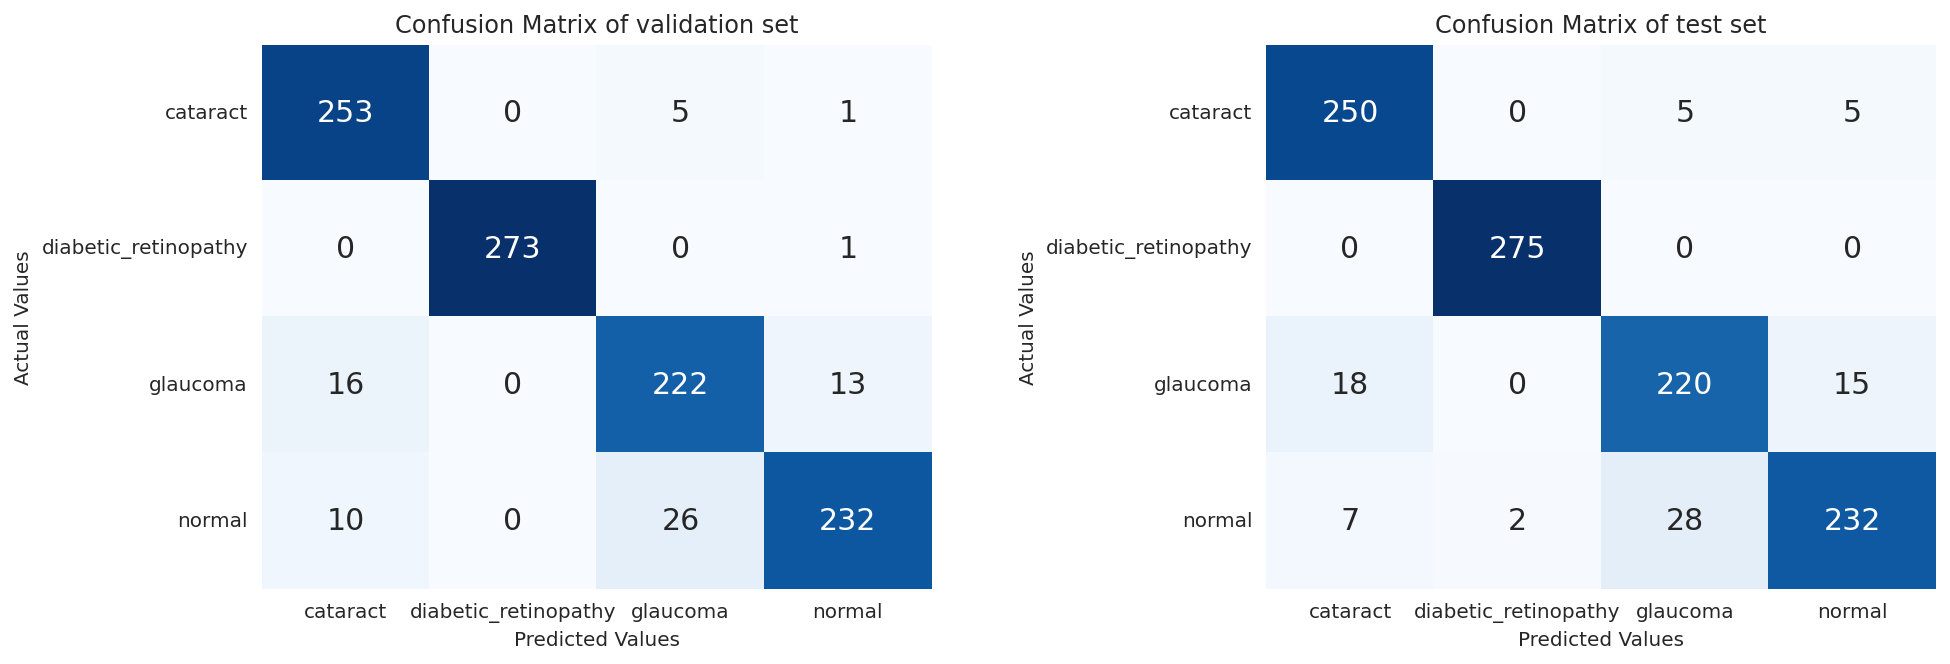

In [50]:
#Plotting confusion matrix using heatmap
fig, axes = plt.subplots(1, 2, figsize=(15,5))
#sns.heatmap(train_cm_df, annot=True, cbar=False, cmap='Blues', vmin=0, fmt='.3g', annot_kws={"size": 15}, ax=axes[0])
#axes[0].set_title('Confusion Matrix of train set')
#axes[0].set_ylabel('Actual Values')
#axes[0].set_xlabel('Predicted Values')

sns.heatmap(val_cm_df, annot=True, cbar=False, cmap='Blues', vmin=0, fmt='.3g', annot_kws={"size": 15}, ax=axes[0])
axes[0].set_title('Confusion Matrix of validation set')
axes[0].set_ylabel('Actual Values')
axes[0].set_xlabel('Predicted Values')

sns.heatmap(test_cm_df, annot=True, cbar=False, cmap='Blues', vmin=0, fmt='.3g', annot_kws={"size": 15}, ax=axes[1])
axes[1].set_title('Confusion Matrix of test set')
axes[1].set_ylabel('Actual Values')
axes[1].set_xlabel('Predicted Values')

plt.subplots_adjust(wspace=0.5)

plt.show()

### Classification report

In [41]:
from sklearn.metrics import classification_report

print(classification_report(test_labels, test_preds, target_names=class_names, digits= 4))

                      precision    recall  f1-score   support

            cataract     0.9091    0.9615    0.9346       260
diabetic_retinopathy     0.9928    1.0000    0.9964       275
            glaucoma     0.8696    0.8696    0.8696       253
              normal     0.9206    0.8625    0.8906       269

           micro avg     0.9243    0.9243    0.9243      1057
           macro avg     0.9230    0.9234    0.9228      1057
        weighted avg     0.9243    0.9243    0.9239      1057
         samples avg     0.9243    0.9243    0.9243      1057



Model is not great at identifying glaucoma from cataract or normal images. This makes sense since these images can look very similar to retinal images with glaucoma. The model is best at identifying diabetic retinopathy.

## Misclassified test images

In [42]:
# extract test file names from test_ds 
test_filenames = test_ds.file_paths

In [43]:
len(test_filenames)

1057

In [44]:
class_names

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']

In [51]:
# convert OHE to class_names for easier comparison 
y_true = tf.argmax(test_labels, axis=1).numpy() # tensor object not iterable, use numpy to convert to list
y_pred = tf.argmax(test_preds, axis=1).numpy()
print('First 5 true labels:', y_true[:5])
print('First 5 predictions:', y_pred[:5])

error_list = []

for a, b, c, d in zip(y_true, y_pred, y_pred_probs, test_filenames):
  if a != b:
    error_list.append((class_names[a],class_names[b],c,d))

First 5 true labels: [0 0 0 0 0]
First 5 predictions: [0 0 2 0 0]


In [52]:
len(error_list)

80

In [54]:
print('Prediction accuracy on test data:', 100 - (len(error_list)*100/len(test_filenames)), '%')

Prediction accuracy on test data: 92.4314096499527 %


### Looking into specific images that were misclassified

In [53]:
error_list[:5] # check formatting

[('cataract',
  'glaucoma',
  0.45664322,
  './work_directory/test/cataract/1102_left.jpg'),
 ('cataract',
  'normal',
  0.5871938,
  './work_directory/test/cataract/119_left.jpg'),
 ('cataract',
  'glaucoma',
  0.452106,
  './work_directory/test/cataract/1415_right.jpg'),
 ('cataract',
  'glaucoma',
  0.57675886,
  './work_directory/test/cataract/1456_left.jpg'),
 ('cataract',
  'normal',
  0.8965301,
  './work_directory/test/cataract/1968_left.jpg')]

[Kaggle reference notebook](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook#Create-a-model-using-transfer-learning-with-EfficientNetB3)

In [55]:
def print_in_color(txt_msg,fore_tupple=(0,255,255),back_tupple=(100,100,100)):
    #prints the text_msg in the foreground color specified by fore_tupple with the background specified by back_tupple 
    #text_msg is the text, fore_tupple is foregroud color tupple (r,g,b), back_tupple is background tupple (r,g,b)
    # default parameter print in cyan foreground and gray background
    rf,gf,bf=fore_tupple
    rb,gb,bb=back_tupple
    msg='{0}' + txt_msg
    mat='\33[38;2;' + str(rf) +';' + str(gf) + ';' + str(bf) + ';48;2;' + str(rb) + ';' +str(gb) + ';' + str(bb) +'m' 
    print(msg .format(mat), flush=True)
    print('\33[0m', flush=True) # returns default print color to back to black
    return

# example default print
msg='test of default colors'
print_in_color(msg)

test of default colors



In [56]:
import re

print ('Below is a list of test files that were misclassified \n')
msg='{0:^10}{1:^30s}{2:^20s}{3:^20s}{4:^15s}'.format('No.','Test File','True Label','Predicted as','Probability')
print_in_color(msg)

for i, (a, b, c, d) in enumerate(error_list):
  x = re.split('./work_directory/test/', d)[-1]
  print('{0:^10}{1:^30s}{2:^20s}{3:^20s}  {4:.4f}'.format(i+1,x,a,b,c))

Below is a list of test files that were misclassified 

   No.              Test File                True Label         Predicted as      Probability  

    1         cataract/1102_left.jpg          cataract            glaucoma        0.4566
    2         cataract/119_left.jpg           cataract             normal         0.5872
    3        cataract/1415_right.jpg          cataract            glaucoma        0.4521
    4         cataract/1456_left.jpg          cataract            glaucoma        0.5768
    5         cataract/1968_left.jpg          cataract             normal         0.8965
    6         cataract/1987_left.jpg          cataract             normal         0.7634
    7        cataract/2140_right.jpg          cataract             normal         0.9665
    8         cataract/81_right.jpg           cataract             normal         0.9680
    9       cataract/_334_6427863.jpg         cataract            glaucoma        0.7199
    10       cataract/_57_3959793.jpg         

In [ ]:
# to display examples of each class that were wrongly classified
fig, axes = plt.subplots(3, 5, figsize=(20, 12)) # 3 rows, 5 cols

def axes_img(r,c,i):
  axes[r,c].imshow(test_images[i].astype('uint8'))
  axes[r,c].axis('off')
  axes[r,c].set_title(f'Actual: {error_list[i][0]} \n Predicted: {error_list[i][1]}', color='blue')

axes_img(r=0,c=0,i=0)  # first row - actual cataract
axes_img(r=0,c=1,i=5)
axes_img(r=0,c=2,i=10)
axes_img(r=0,c=3,i=15)
axes_img(r=0,c=4,i=20)

axes_img(r=1,c=0,i=23) # 2nd row - actual glaucoma 
axes_img(r=1,c=1,i=29)
axes_img(r=1,c=2,i=35)
axes_img(r=1,c=3,i=42)
axes_img(r=1,c=4,i=48)

axes_img(r=2,c=0,i=50) # 3rd row - actual normal
axes_img(r=2,c=1,i=54) 
axes_img(r=2,c=2,i=62)
axes_img(r=2,c=3,i=68)
axes_img(r=2,c=4,i=73)

plt.subplots_adjust(hspace=0.28) # add space between rows
plt.show()

### ROC curve only if comparing with another model

In [ ]:
# ROC curve

In [ ]:
# PR curve

## Convert model to TF Lite model version for production use

[Reference](https://towardsdatascience.com/a-basic-introduction-to-tensorflow-lite-59e480c57292)